In [2]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from random import gauss
from arch import arch_model
from stock_simulator import gbm, rolling_volatility,wiener_process


In [5]:
def simulate_garch(n_steps = 252,mu = 0.005, omega = 0.00001, alpha = 0.1, beta = 0.87, start_price=100, n_paths = 1, seed=42):
    '''Simulate stock prices using a GARCH(1,1) model.
    Parameters:
    n_steps: int, number of time steps to simulate (default: 252)
    mu: float, mean return (default: 0.005)
    omega: float, constant term in the GARCH model (default: 0.00001)
    alpha: float, coefficient for lagged squared returns (default: 0.1)
    beta: float, coefficient for lagged conditional variance (default: 0.87)
    start_price: float, initial stock price (default: 100)
    n_paths: int, number of paths to simulate (default: 1)
    seed: int, random seed for reproducibility (default: 42)
    Returns:
    prices: pd.DataFrame, simulated stock prices
    vol: pd.DataFrame, rolling volatility of the simulated stock prices
    '''
    np.random.seed(seed)
    if n_paths > 1:
        prices = np.empty((n_steps + 1, n_paths))
        returns = np.empty((n_steps + 1, n_paths))
        prices[0] = start_price
        sim = arch_model(None, mean= "constant", vol='Garch', p=1, q=1, dist='normal')
        sim.distribution.random_state = np.random.RandomState(seed)
        for p in range(n_paths):
            simulated=sim.simulate([mu, omega, alpha, beta], nobs=n_steps, burn=100)
            returns[1:, p] = simulated["data"].values  # returns already in decimal
            prices[1:, p] = start_price * np.cumprod(1 + returns[1:, p])
        prices = pd.DataFrame(prices, columns=[f"Path_{i}" for i in range(n_paths)])
        vol = rolling_volatility(prices, window_size=20)
        returns = pd.DataFrame(returns, columns=[f"Path_{i}" for i in range(n_paths)])
        return prices, vol, returns
    simulated=sim.simulate([mu, omega, alpha, beta], nobs=n_steps, burn=100)
    prices = np.empty((n_steps, 1))
    prices[0] = start_price
    returns = simulated["data"].values  # returns already in decimal
    prices = start_price * np.cumprod(1 + returns)
    prices = pd.DataFrame(prices, columns=["Price"])
    vol = rolling_volatility(prices, window_size=20)
    returns = pd.DataFrame(returns, columns=["Return"])


    return prices, vol, returns

In [6]:
prices, volatility, returns = simulate_garch(n_paths=3)

<Axes: title={'center': 'Simulated Stock Prices from GARCH(1,1) Model'}, xlabel='Time Steps', ylabel='Price'>

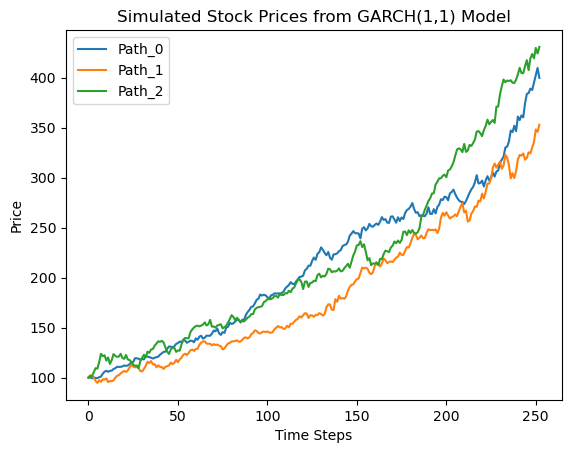

In [148]:

prices.plot(title='Simulated Stock Prices from GARCH(1,1) Model', ylabel='Price', xlabel='Time Steps')


<Axes: title={'center': 'Rolling Volatility of Simulated Stock Prices'}, xlabel='Time Steps', ylabel='Volatility'>

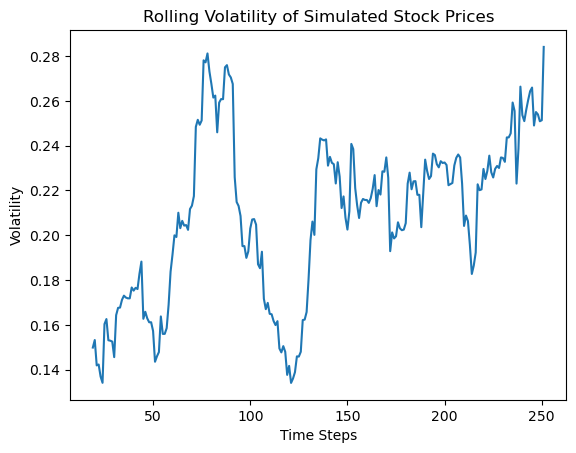

In [149]:
volatility.plot(title='Rolling Volatility of Simulated Stock Prices', ylabel='Volatility', xlabel='Time Steps')


<Axes: title={'center': 'Simulated Returns from GARCH(1,1) Model'}, xlabel='Time Steps', ylabel='Return'>

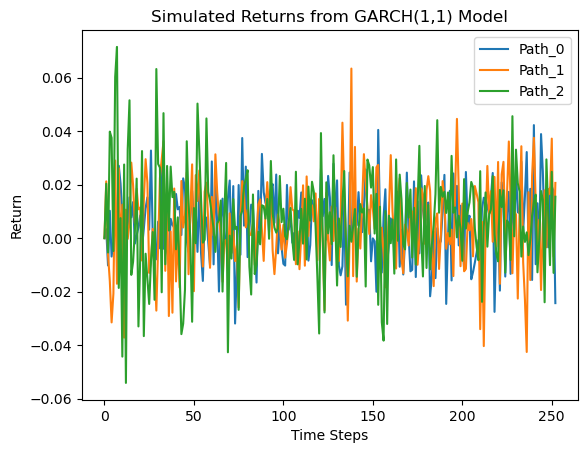

In [150]:
returns.plot(title='Simulated Returns from GARCH(1,1) Model', ylabel='Return', xlabel='Time Steps')

In [17]:
print("Return stats:")
print(f"  Mean:  {returns.mean():.6f}")
print(f"  Std:   {returns.std():.6f}")
print(f"  Min:   {returns.min():.6f}")
print(f"  Max:   {returns.max():.6f}")

print("\nVolatility stats:")
print(f"  Mean:  {volatility.mean():.6f}")
print(f"  Min:   {volatility.min():.6f}")
print(f"  Max:   {volatility.max():.6f}")
print(f"  Annualized mean: {volatility.mean() * np.sqrt(252):.4f}")

Return stats:
  Mean:  -0.008468
  Std:   0.861602
  Min:   -2.511169
  Max:   3.328143

Volatility stats:
  Mean:  0.899154
  Min:   0.020000
  Max:   1.353336
  Annualized mean: 14.2736


In [9]:
predictor = arch_model(returns["Path_0"], mean='constant', vol='Garch', p=1, q=1)
model_fit = predictor.fit(disp='off')

/opt/anaconda3/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003177. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [53]:
returns.max()

3.328142550561261

In [137]:
stock = gbm(n_paths=1, n_steps=252, mu=0.2, sigma=0.2, S0=100)

In [138]:
stock_series = pd.Series(stock["Path_0"].values.flatten(), index=pd.date_range(start='2020-01-01', periods=252, freq='B'))

<Axes: title={'center': 'GBM Simulated Stock Prices'}, xlabel='Time', ylabel='Price'>

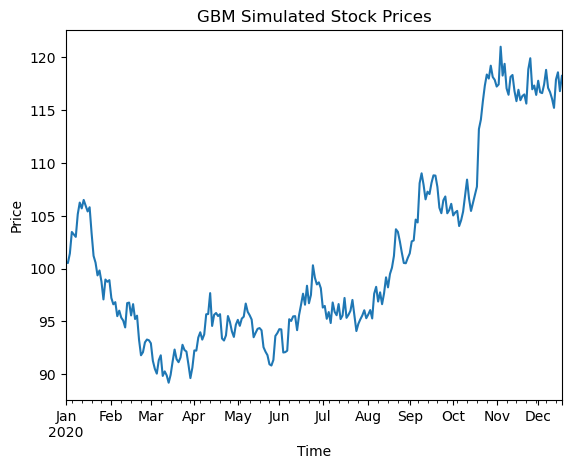

In [140]:
stock_series.plot(title='GBM Simulated Stock Prices', ylabel='Price', xlabel='Time')

<Axes: title={'center': 'GBM Simulated Stock Returns'}>

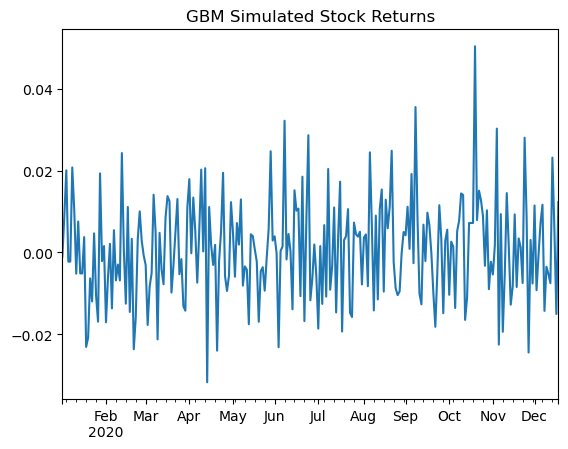

In [139]:
stock_series.pct_change().dropna().plot(title='GBM Simulated Stock Returns')

In [117]:
sim = arch_model(None, mean= "constant", vol='Garch', p=1, q=1, dist='normal')
simulated=sim.simulate([0.005, 0.00001, 0.03, 0.87], nobs=252, burn=100)

In [141]:
prices = np.empty((252, 1))
prices[0] = 100
s = sim.simulate([0.005, 0.00001, 0.03, 0.87], nobs=252, burn=100)
r = s["data"].values  # returns already in decimal
prices = 100 * np.cumprod(1 + r)

In [142]:
type(r)

numpy.ndarray

<Axes: title={'center': 'GARCH Simulated Stock Prices'}, xlabel='Time', ylabel='Price'>

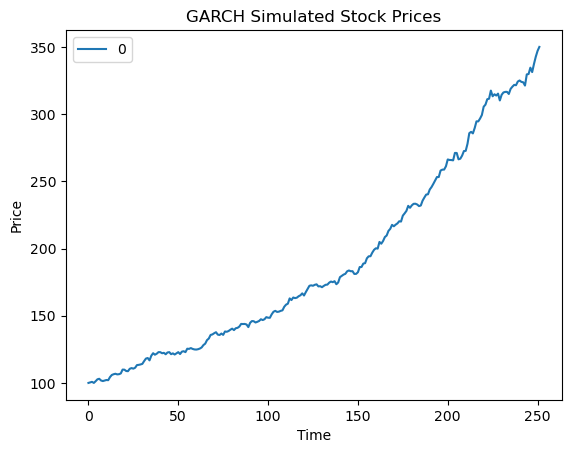

In [123]:
pd.DataFrame(prices).plot(title='GARCH Simulated Stock Prices', ylabel='Price', xlabel='Time')

<Axes: title={'center': 'Simulated GARCH(1,1) Returns'}>

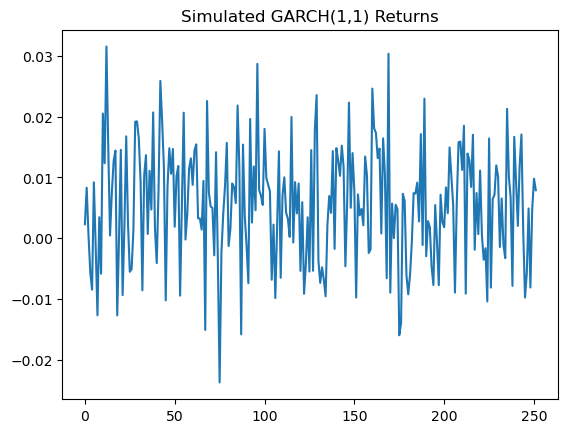

In [124]:
simulated['data'].plot(title='Simulated GARCH(1,1) Returns')

<Axes: title={'center': 'Simulated GARCH(1,1) Volatility'}>

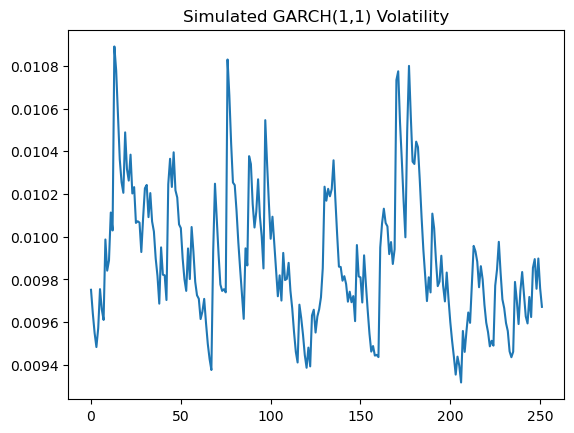

In [125]:
simulated["volatility"].plot(title='Simulated GARCH(1,1) Volatility')

In [24]:
simulated.describe()

,data,volatility,errors
count,252.000000,252.000000,252.000000
mean,0.005240,0.008370,0.000240
std,0.008391,0.000349,0.008391
min,-0.016687,0.007761,-0.021687
25%,-0.000198,0.008114,-0.005198
50%,0.005424,0.008337,0.000424
75%,0.011659,0.008585,0.006659
max,0.026165,0.009364,0.021165


<Axes: title={'center': 'Rolling Volatility (20-day) of GBM Returns'}>

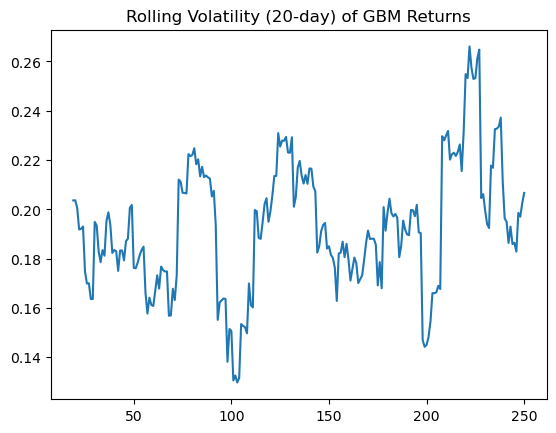

In [3]:
rolling_volatility(stock, window_size=20).plot(title='Rolling Volatility (20-day) of GBM Returns')

In [65]:
stock = gbm(n_paths = 3)

<Axes: title={'center': 'GBM Simulated Stock Prices'}, xlabel='Time', ylabel='Price'>

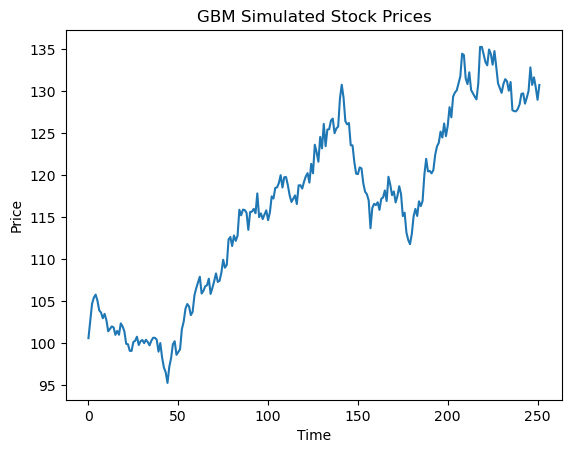

In [66]:
stock["Path_0"].plot(title='GBM Simulated Stock Prices', ylabel='Price', xlabel='Time')

<Axes: title={'center': 'Rolling Volatility (20-day) of GBM Returns for Path 2'}>

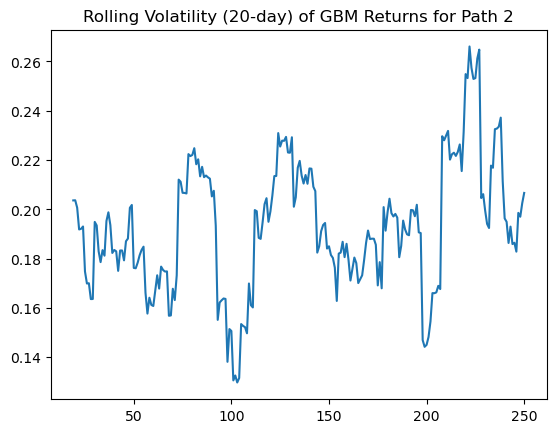

In [30]:
rolling_volatility(stock, window_size=20, path=0).plot(title='Rolling Volatility (20-day) of GBM Returns for Path 2')

In [7]:
trained = arch_model(simulated["data"]*100, vol="Garch", p=1, q=1).fit(disp="off")

NameError: name 'simulated' is not defined

In [93]:
trained.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   data   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -362.766
Distribution:                  Normal   AIC:                           733.532
Method:            Maximum Likelihood   BIC:                           747.650
                                        No. Observations:                  252
Date:                Tue, Jul 14 2026   Df Residuals:                      251
Time:                        08:59:10   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.6180  6.404e-02      9.651  4.879e-22 [  0.493,  0.744]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0367  2.659e-02      1.381      0.167 [-1.538e-02,8.885e-02]
alpha[1]   4.0031e-14  1.705e-02  2.347e-12      1.000 [-3.342e-02,3.342e-02]
beta[1]        0.9626  3.637e-02     26.471 2.119e-154      [  0.891,  1.034]
=============================================================================

Covariance estimator: robust
"""